In [6]:
import pandas as pd
import scanpy as sc
sc.settings.verbosity = 3  
sc.logging.print_header()
sc.settings.set_figure_params(dpi=200, facecolor="white")
adata = sc.read_10x_h5("/data2/chenruipu/data/xulingna/snp/scRNA/20250312_electrorotation/result/electrorotation/outs/raw_feature_bc_matrix.h5")

scanpy==1.10.1 anndata==0.10.7 umap==0.5.5 numpy==1.26.4 scipy==1.13.0 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.1 igraph==0.10.4 louvain==0.8.2 pynndescent==0.5.12
reading /data2/chenruipu/data/xulingna/snp/scRNA/20250312_electrorotation/result/electrorotation/outs/raw_feature_bc_matrix.h5
 (0:00:02)


/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [8]:
import pandas as pd
electroporation_snp = pd.read_csv('electropration_snp_counts.csv')
electroporation_snp['scRNA_region'] = electroporation_snp['snp_id']
electroporation_snp['snp_id'] = electroporation_snp['snp_id'].str.split('::').str[0]
starr_seq_snp =  pd.read_csv('/data2/chenruipu/data/xulingna/snp/M18_effective_snp_eQTL_TF_female.tsv',sep='\t')
overlap = pd.merge(electroporation_snp,starr_seq_snp,on='snp_id',how='inner')
region = list(set(overlap['scRNA_region'].to_list()))
target = [f"{g}_ref" for g in region] + [f"{g}_alt" for g in region]
#adata.var_names_make_unique()


In [4]:
import numpy as np


adata.var_names_make_unique()
X = adata[:, target].X

if not isinstance(X, np.ndarray):
    X = X.toarray()

# 所有基因表达值都 > 0
mask = (X > 0).any(axis=1)
print(set(mask))
adata = adata[mask].copy()

{False, True}


In [5]:

#sc.pl.highest_expr_genes(adata, n_top=20)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# # annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(
	adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
adata = adata[adata.obs.n_genes_by_counts < 8000, :].copy()
adata = adata[adata.obs.pct_counts_mt < 10, :].copy()

filtered out 23045 cells that have less than 200 genes expressed
filtered out 28017 genes that are detected in less than 3 cells


In [6]:
adata

AnnData object with n_obs × n_vars = 4626 × 20922
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [7]:

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


    finished (0:00:15)
computing PCA
    with n_comps=50
    finished (0:00:00)


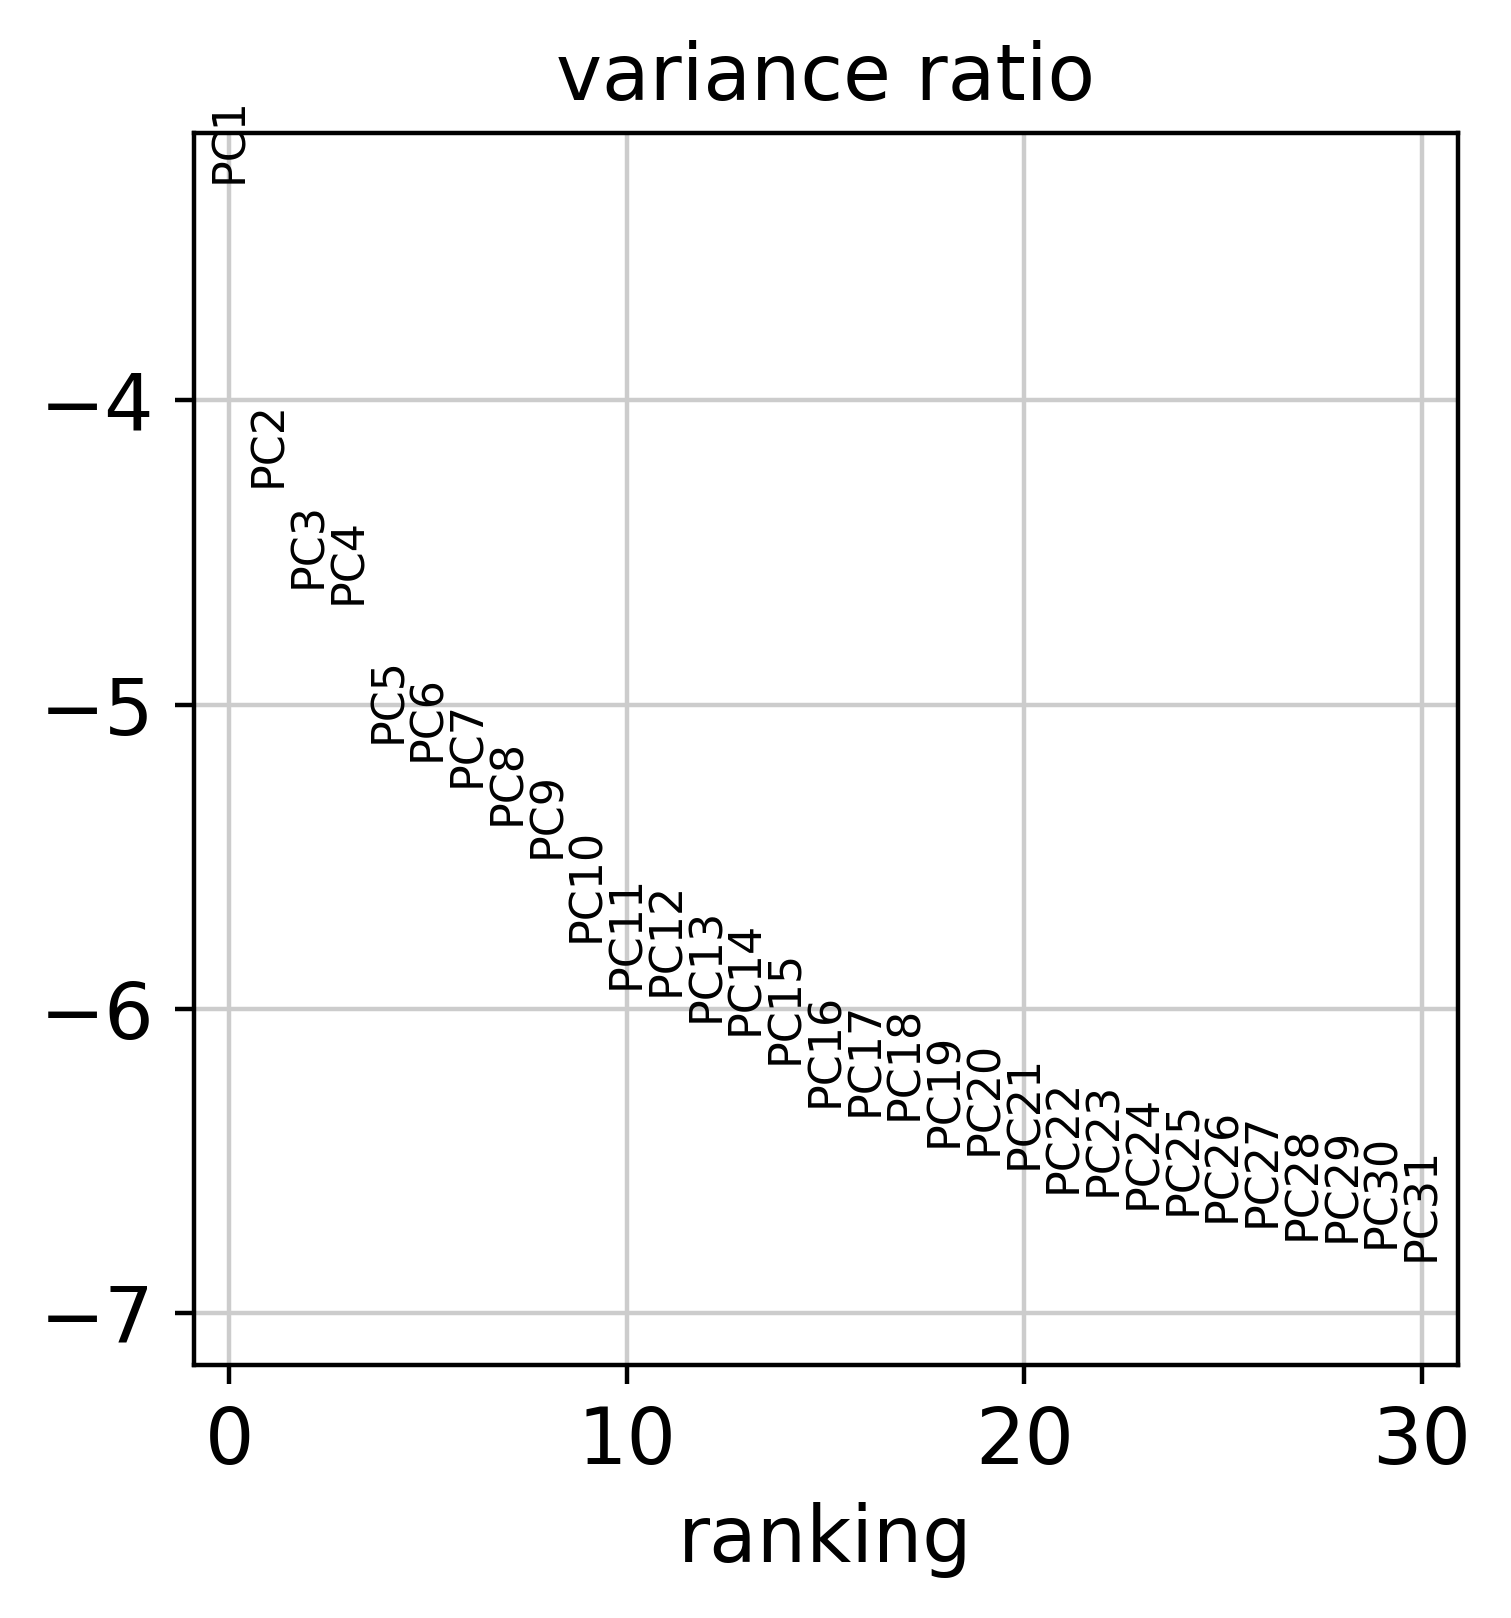

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
running Leiden clustering


/tmp/ipykernel_259606/966185621.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)
computing tSNE
    using 'X_pca' with n_pcs = 50
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:00:10)
running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


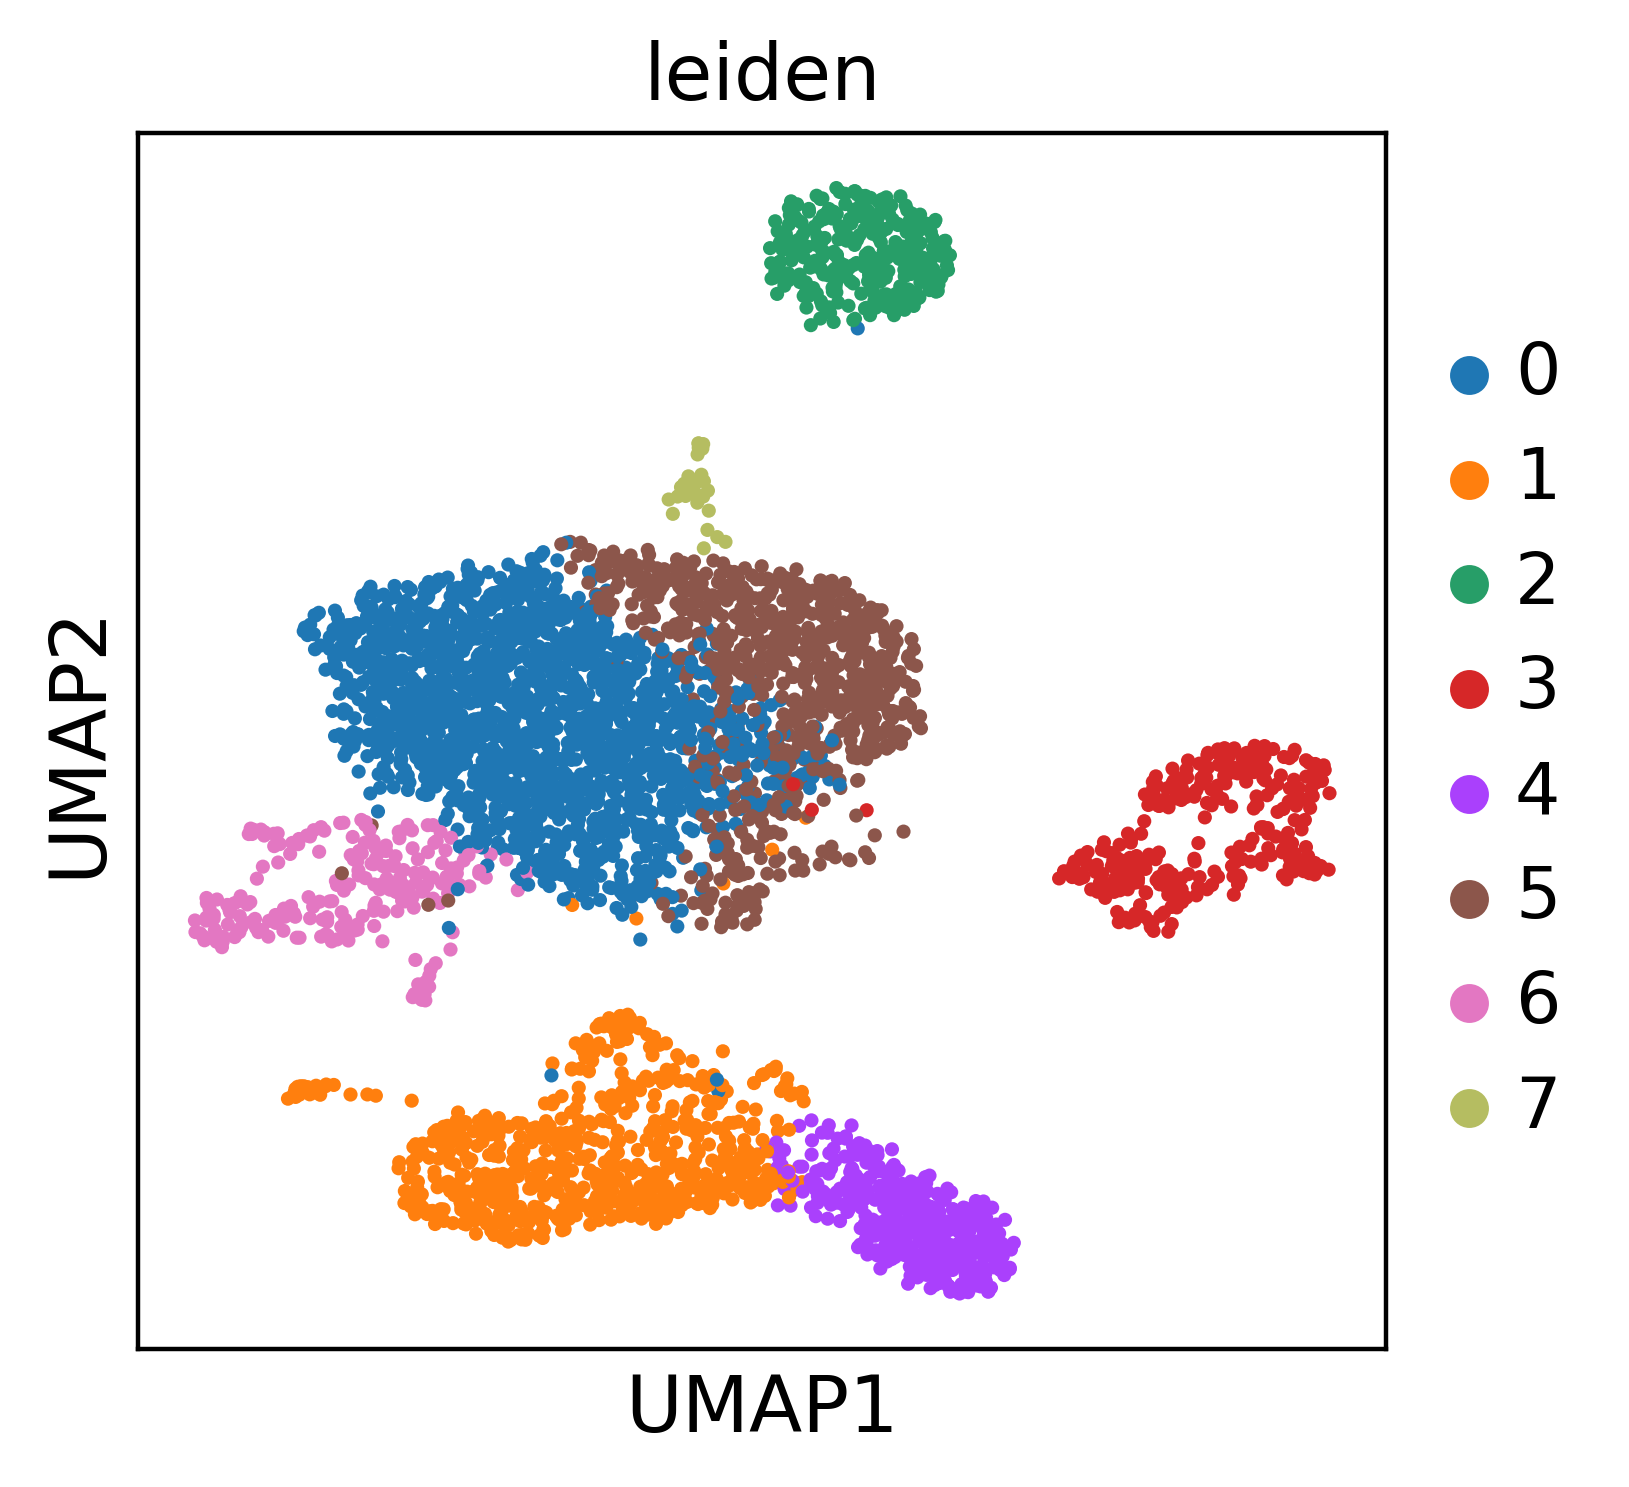

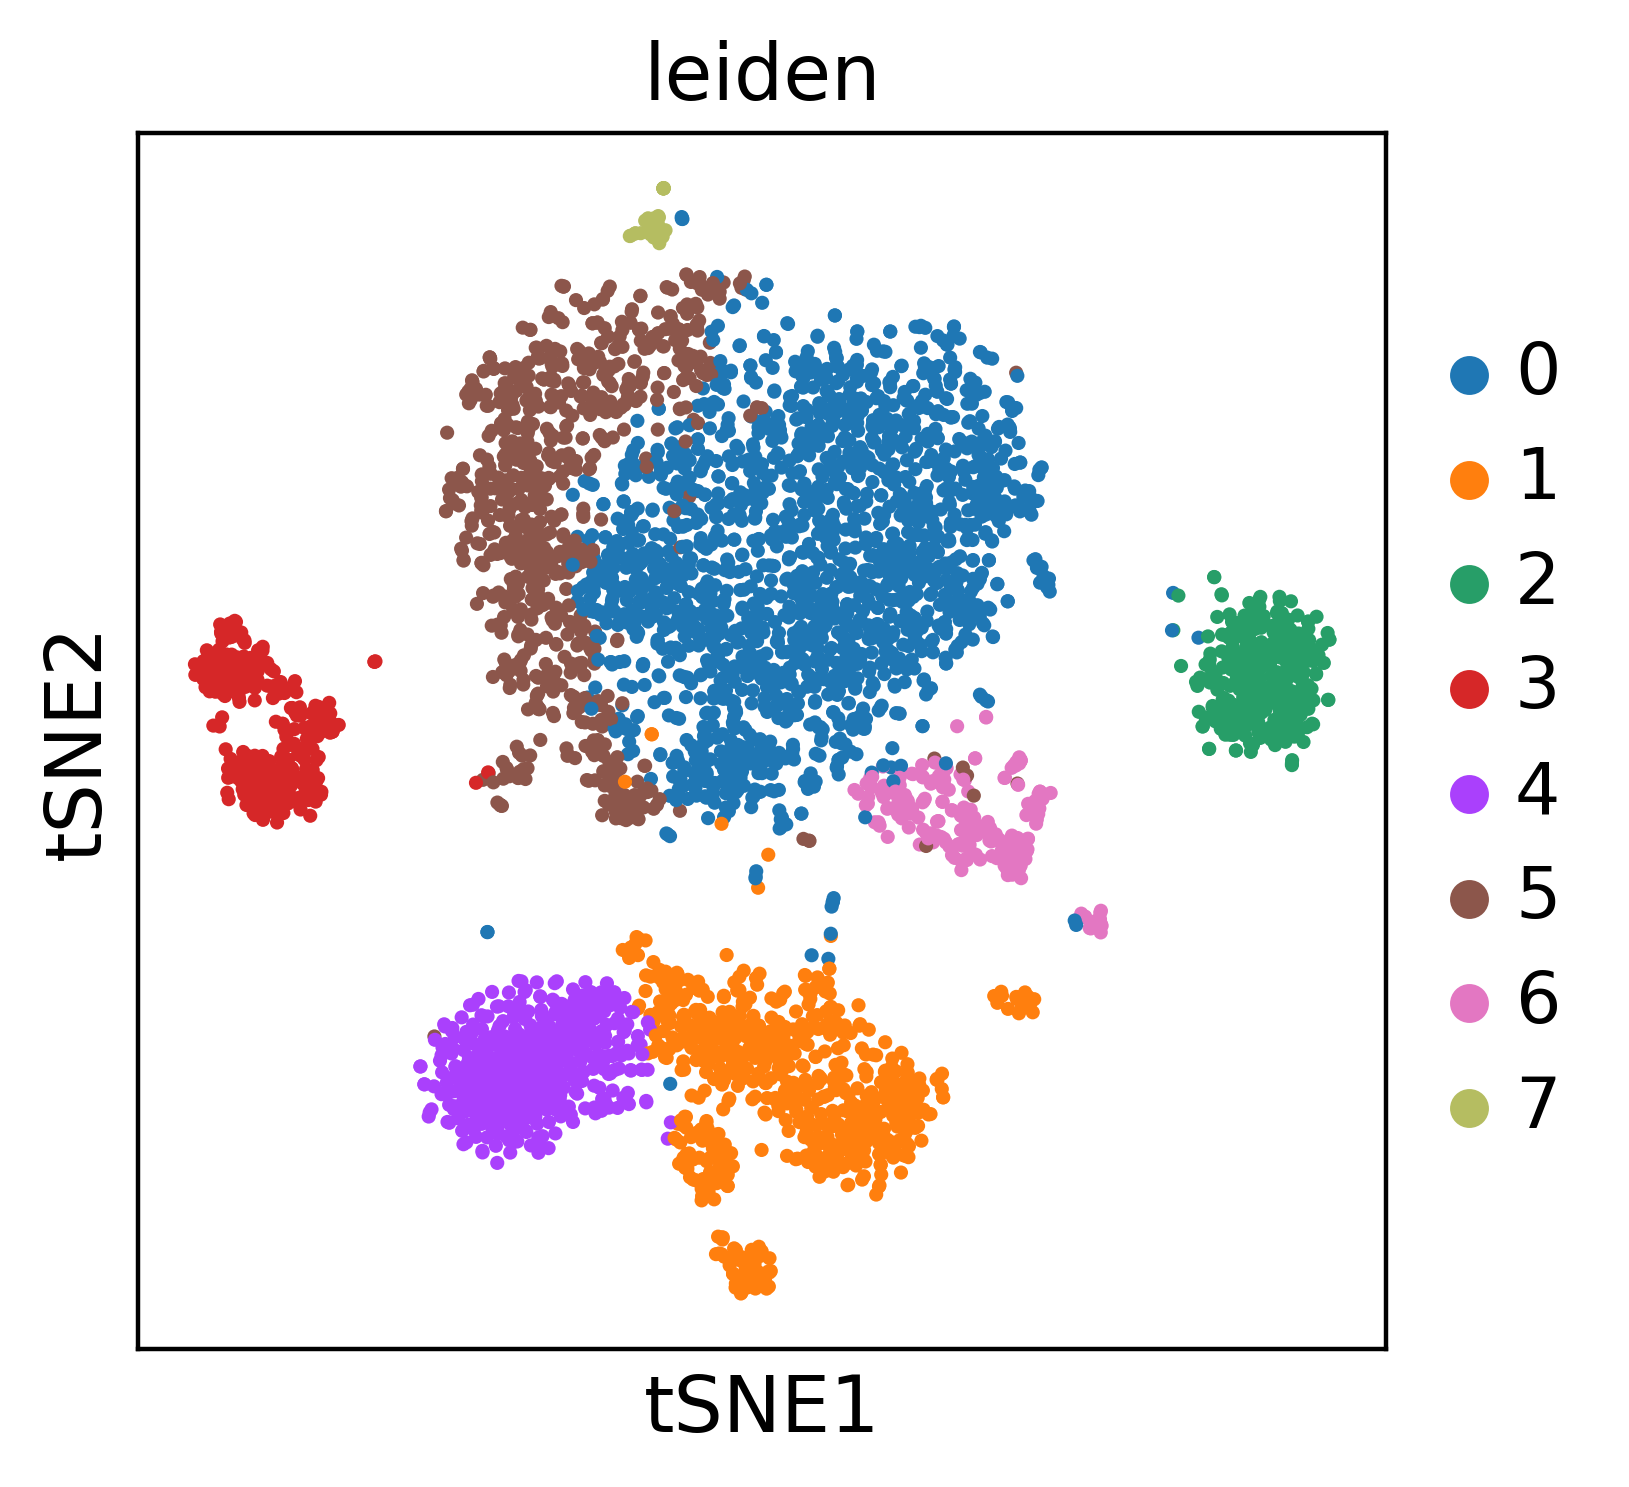

In [8]:

adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True)
sc.pp.neighbors(adata)
sc.tl.leiden(adata)
sc.tl.paga(adata)
sc.pl.paga(adata, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
sc.tl.umap(adata)
sc.tl.tsne(adata)
sc.tl.leiden(
	adata,
	resolution=0.3,
	random_state=0,
	flavor="igraph",
	n_iterations=-1,
	directed=False,
)
sc.pl.umap(adata, color=["leiden"])
sc.pl.tsne(adata, color=["leiden"])

In [9]:
import scanpy as sc

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",     # 按聚类结果分组
    method="t-test",      # 或 'wilcoxon' (更常用)
    n_genes=adata.shape[1]  # 全部基因都考虑
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in

In [5]:
def top_n_markers(adata, n=5, key='rank_genes_groups'):
    result = adata.uns[key]
    clusters = result['names'].dtype.names  # cluster 名称列表
    top_genes = {}
    for cluster in clusters:
        genes = result['names'][cluster][:n]  # 前 n 个基因
        top_genes[cluster] = list(genes)
    return top_genes

top5_per_cluster = top_n_markers(adata, n=5)

# 查看结果
for cluster, genes in top5_per_cluster.items():
    print(f"Cluster {cluster}: {genes}")

Cluster 0: ['Pde4d', 'Osbpl8', 'Apoe', 'Gpnmb', 'Gatm']
Cluster 1: ['Mustn1', 'Tnni2', 'Des', 'Slc25a4', 'Cox6a2']
Cluster 2: ['Thbs1', 'Fmnl2', 'Srgn', 'Cxcl3', 'S100a11']
Cluster 3: ['Clec4d', 'Srgn', 'Ccl3', 'Cd9', 'Msrb1']
Cluster 4: ['Tk1', 'Ccna2', 'Pf4', 'Cenpf', 'Sgol1']
Cluster 5: ['Ms4a4c', 'Fpr1', 'Samsn1', 'Fpr2', 'Plac8']
Cluster 6: ['Stmn1', 'Rrm1', '2810417H13Rik', 'Dut', 'Atad2']
Cluster 7: ['C1qa', 'C1qc', 'C1qb', 'Sepp1', 'Hmgn1']


In [8]:
import scanpy as sc
adata = sc.read_h5ad("electroporation_snp_scRNA_onlytarget_1106.h5ad")

In [9]:
adata.obs

,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,cell_type
AAACCCACAGACTCTA-1,4992,4991,24399.0,118.0,0.483626,0,FAPs
AAACCCACATCACGGC-1,411,411,642.0,7.0,1.090343,1,Muscle cell
AAACGAAAGTAAGCAT-1,5169,5169,29850.0,190.0,0.636516,0,FAPs
AAACGAACAGGGTCTC-1,5689,5687,36254.0,279.0,0.769570,0,FAPs
AAACGAACAGTCGGTC-1,870,870,1857.0,2.0,0.107701,1,Muscle cell
...,...,...,...,...,...,...,...
TTTGGTTGTGTCATCA-1,5741,5741,33959.0,223.0,0.656674,0,FAPs
TTTGTTGAGTTCCGTA-1,5432,5431,30519.0,224.0,0.733969,0,FAPs
TTTGTTGCAGACGATG-1,1656,1656,5742.0,52.0,0.905608,1,Muscle cell
TTTGTTGGTAGGTAGC-1,4716,4715,24157.0,113.0,0.467773,0,FAPs


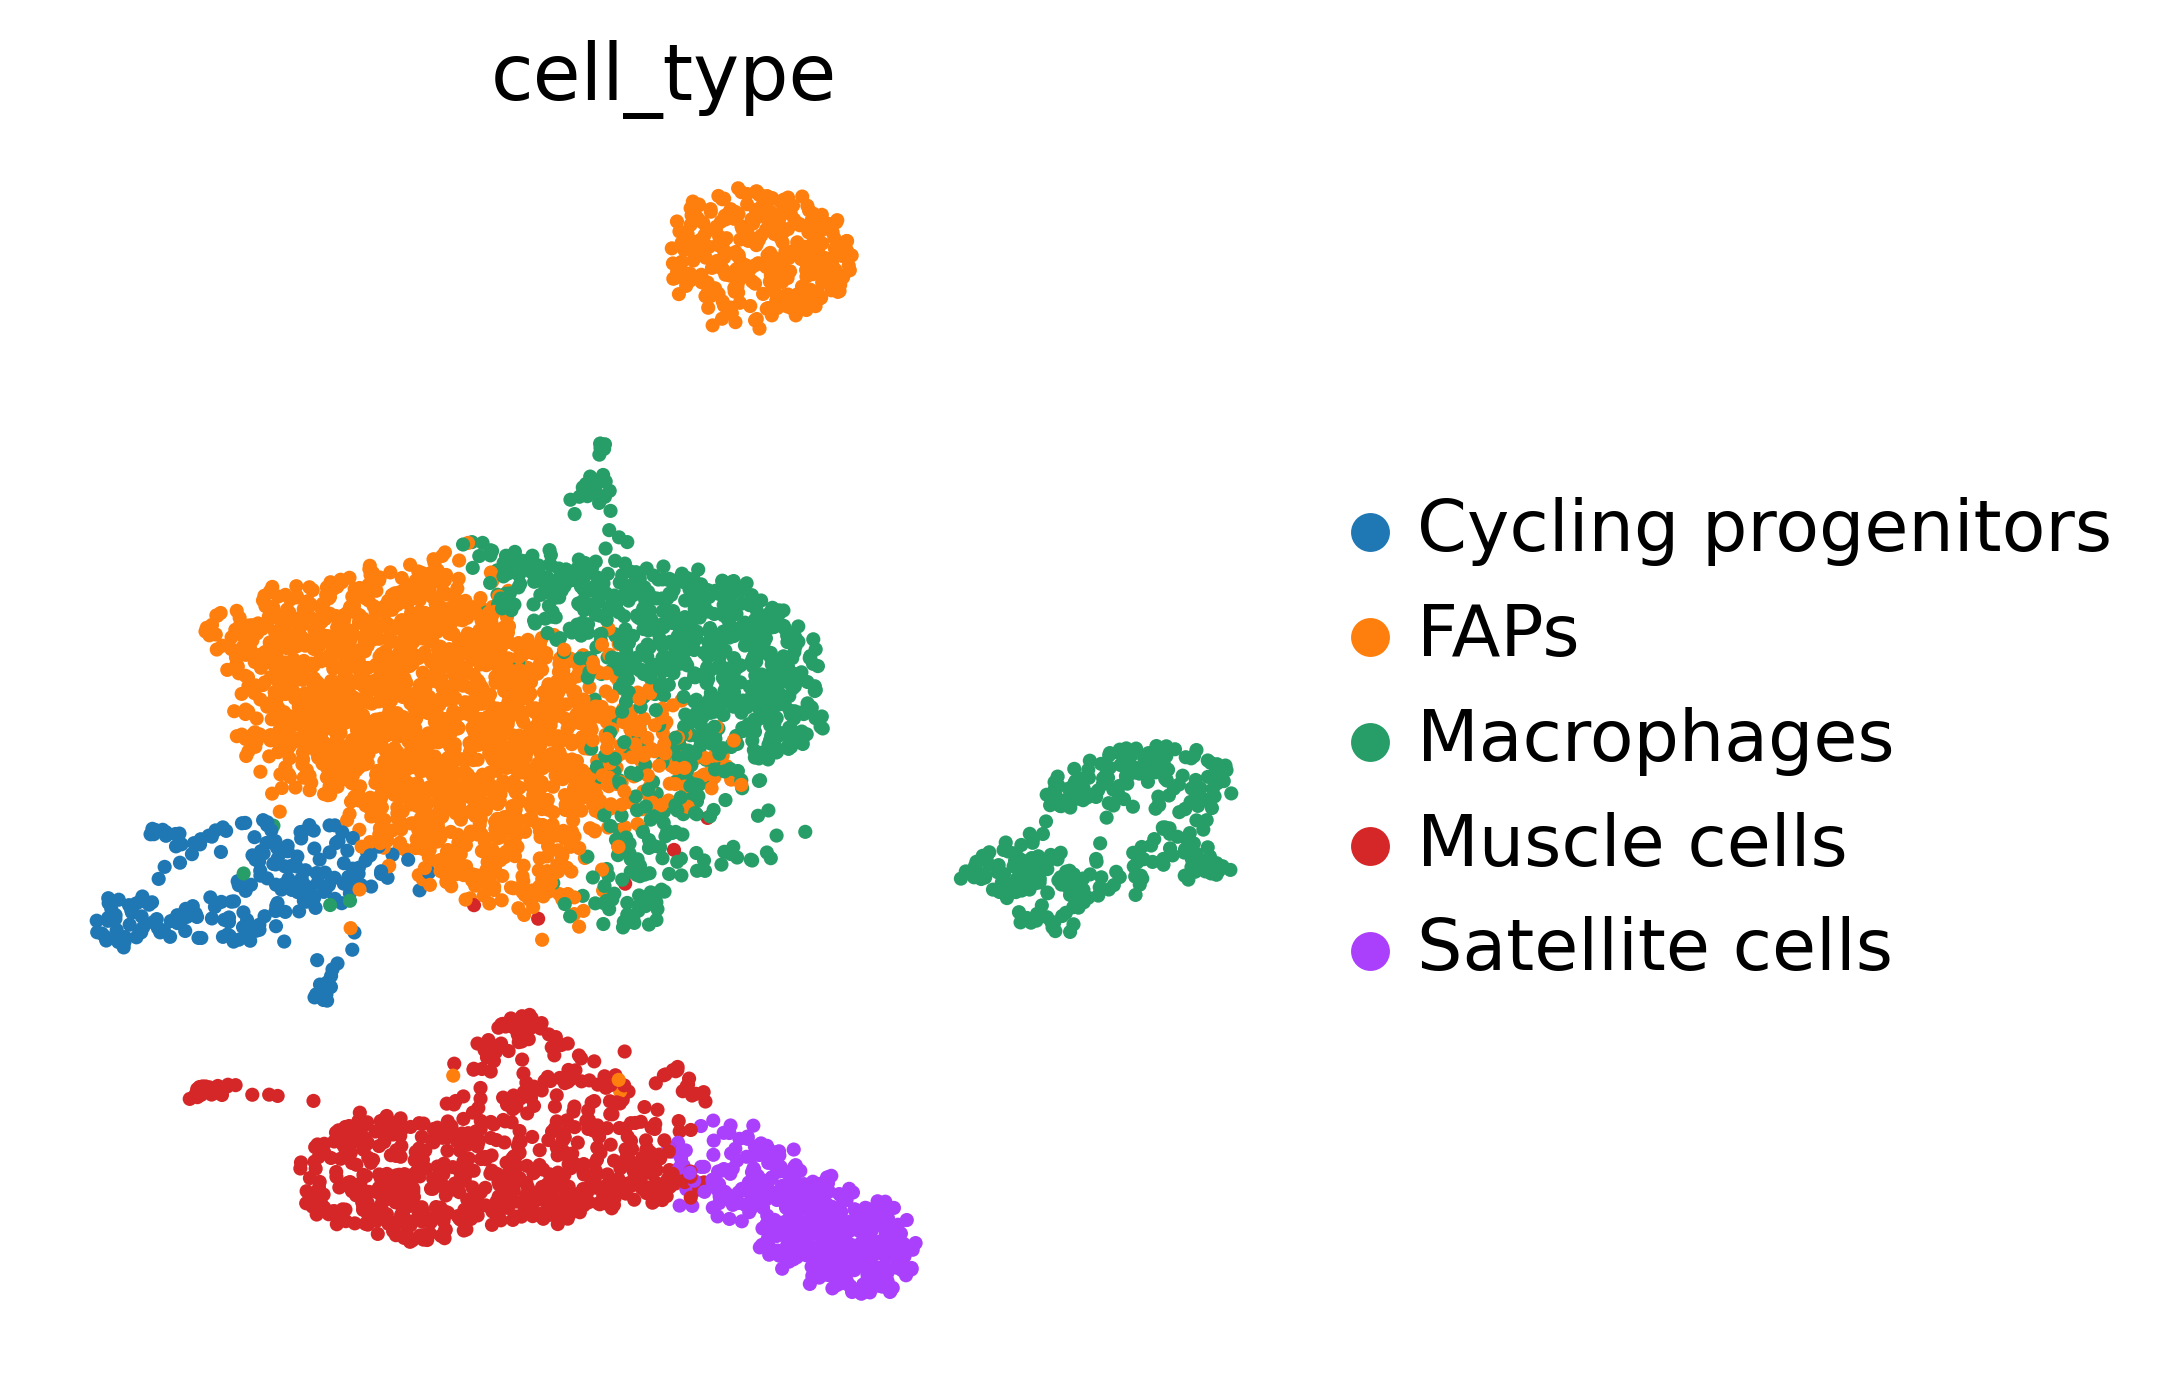

In [10]:
cluster_to_celltype = {
    "0": "FAPs",
    "1": "Muscle cells",
    "2": "FAPs",
    "3": "Macrophages",
    "4": "Satellite cells",
    "5": "Macrophages",
    "6": "Cycling progenitors",
    "7": "Macrophages"
}

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_to_celltype)

sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False
)

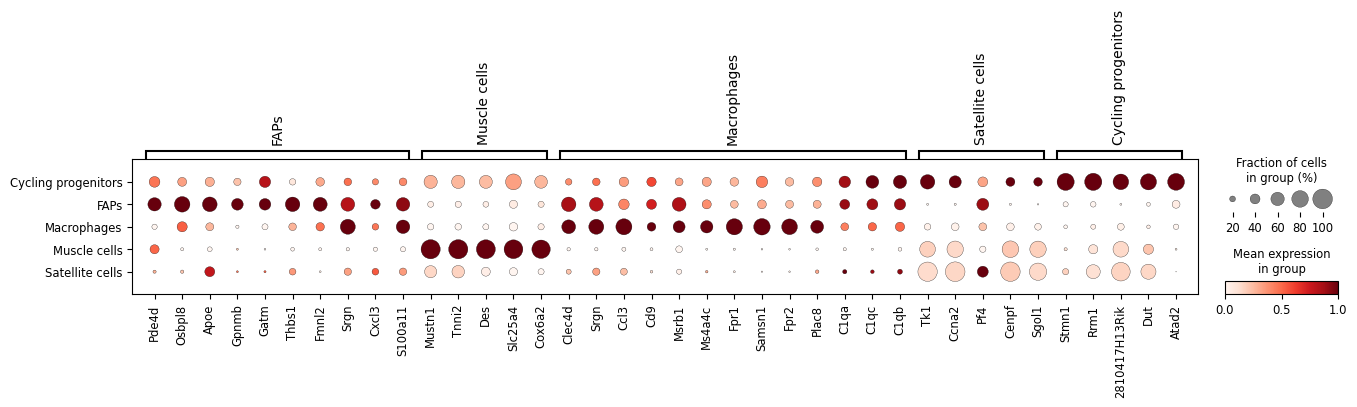

In [43]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 示例：计算每个 cluster 中 marker 平均表达量
marker_dict = {
    "FAPs": [
        "Pde4d","Osbpl8","Apoe","Gpnmb","Gatm",
        "Thbs1","Fmnl2","Srgn","Cxcl3","S100a11"
    ],
    
    "Muscle cells": [
        "Mustn1","Tnni2","Des","Slc25a4","Cox6a2"
    ],
    
    "Macrophages": [
        "Clec4d","Srgn","Ccl3","Cd9","Msrb1",
        "Ms4a4c","Fpr1","Samsn1","Fpr2","Plac8",
        "C1qa","C1qc","C1qb"
    ],
    
    "Satellite cells": [
        "Tk1","Ccna2","Pf4","Cenpf","Sgol1"
    ],
    
    "Cycling progenitors": [
        "Stmn1","Rrm1","2810417H13Rik","Dut","Atad2"
    ]
}


sc.pl.dotplot(adata, marker_dict, groupby="cell_type", standard_scale="var",save='_cell_type_marker_dotplot.pdf',)



In [21]:
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.stats as stats 
from Bio import SeqIO
#adata= sc.read_h5ad('electroporation_snp_scRNA_onlytarget_1106.h5ad')
#adata.obs['cell_type']=adata.obs['leiden']
adata_raw = sc.read_10x_h5("/data2/chenruipu/data/xulingna/snp/scRNA/20250312_electrorotation/result/electrorotation/outs/raw_feature_bc_matrix.h5")
adata_raw.var_names_make_unique()
adata_raw = adata_raw[adata.obs_names,:]
adata_raw.obs = adata.obs
cell_type_allele = pd.DataFrame(columns=['snp_id','cell_type','ref_nsnp','ref_ncell','alt_nsnp','alt_ncell','fisher_p-value'])
for cell_type in ['FAPs','Muscle cells','Macrophages','Cycling progenitors','Satellite cells']:
	# for snp in 
	tmp_adata = adata_raw[adata_raw.obs['cell_type']==cell_type]
	#print(tmp_adata)
	#sc.pp.filter_cells(tmp_adata, min_genes=200)
	#sc.pp.filter_genes(tmp_adata, min_cells=5)
	# # annotate the group of mitochondrial genes as "mt"
	tmp_adata.var["mt"] = tmp_adata.var_names.str.startswith("mt-")
	sc.pp.calculate_qc_metrics(tmp_adata,qc_vars=["mt"],percent_top=None, log1p=False, inplace=True)
	for record in SeqIO.parse('/data2/chenruipu/data/xulingna/snp/scRNA/scripts/snpM18_ref.fasta','fasta'):
		snp_id = str(record.id).split('_')[0]
		#print(f'{snp_id}')
		if tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_ref']['n_cells_by_counts'].values.size>0 :
			ref_ncell = int(tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_ref']['n_cells_by_counts'].values[0])
		else : 
			ref_ncell = 0
		if tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_ref']['total_counts'].values.size>0:
			ref_nsnp= int(tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_ref']['total_counts'].values[0])
		else : 
			ref_nsnp= 0
		if tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_alt']['n_cells_by_counts'].values.size >0 :
			alt_ncell = int(tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_alt']['n_cells_by_counts'].values[0])
		else:
			alt_ncell = 0
		if tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_alt']['total_counts'].values.size > 0:
			
			alt_nsnp =int(tmp_adata.var[tmp_adata.var['gene_ids']==f'{snp_id}_alt']['total_counts'].values[0])
		else:
			alt_nsnp = 0 
		#print(ref_nsnp,alt_nsnp,ref_ncell,alt_ncell)
		table= [[ref_nsnp,alt_nsnp],[ref_ncell,alt_ncell]]
		#print(table)
		oddsratio, p_value = stats.fisher_exact(table)
		# print(f"Odds Ratio: {oddsratio}")
		# print(f"P-value: {p_value}")
		new_row = pd.DataFrame([{'snp_id': snp_id, 'cell_type':cell_type, 'ref_nsnp':ref_nsnp,'alt_nsnp':alt_nsnp,'ref_ncell':ref_ncell,'alt_ncell':alt_ncell,'fisher_p-value':p_value}])
		cell_type_allele = pd.concat([cell_type_allele,new_row],ignore_index=True)
cell_type_allele=cell_type_allele[(cell_type_allele['snp_id'].isin([t.split('_')[0] for t in target]))]
cell_type_allele.to_csv('eletroporation_cell_type_allele.csv',index=False)

/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_162558/2347880479.py:20: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  tmp_adata.var["mt"] = tmp_adata.var_names.str.startswith("mt-")
/tmp/ipykernel_162558/2347880479.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operat

In [12]:
cell_type_allele=pd.read_csv('eletroporation_cell_type_allele.csv')

In [13]:
target_counts = cell_type_allele[['cell_type','ref_nsnp','alt_nsnp']].groupby('cell_type').sum().reset_index()
target_counts['total'] = target_counts['ref_nsnp'] + target_counts['alt_nsnp']
target_counts['cell_type'] = target_counts['cell_type'].astype('str')
target_counts = cell_type_allele[['snp_id','ref_nsnp','alt_nsnp']].groupby('snp_id').sum().reset_index()

/tmp/ipykernel_255451/2934354552.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_255451/2934354552.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_255451/2934354552.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cell_order, fontsize=16)
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' 

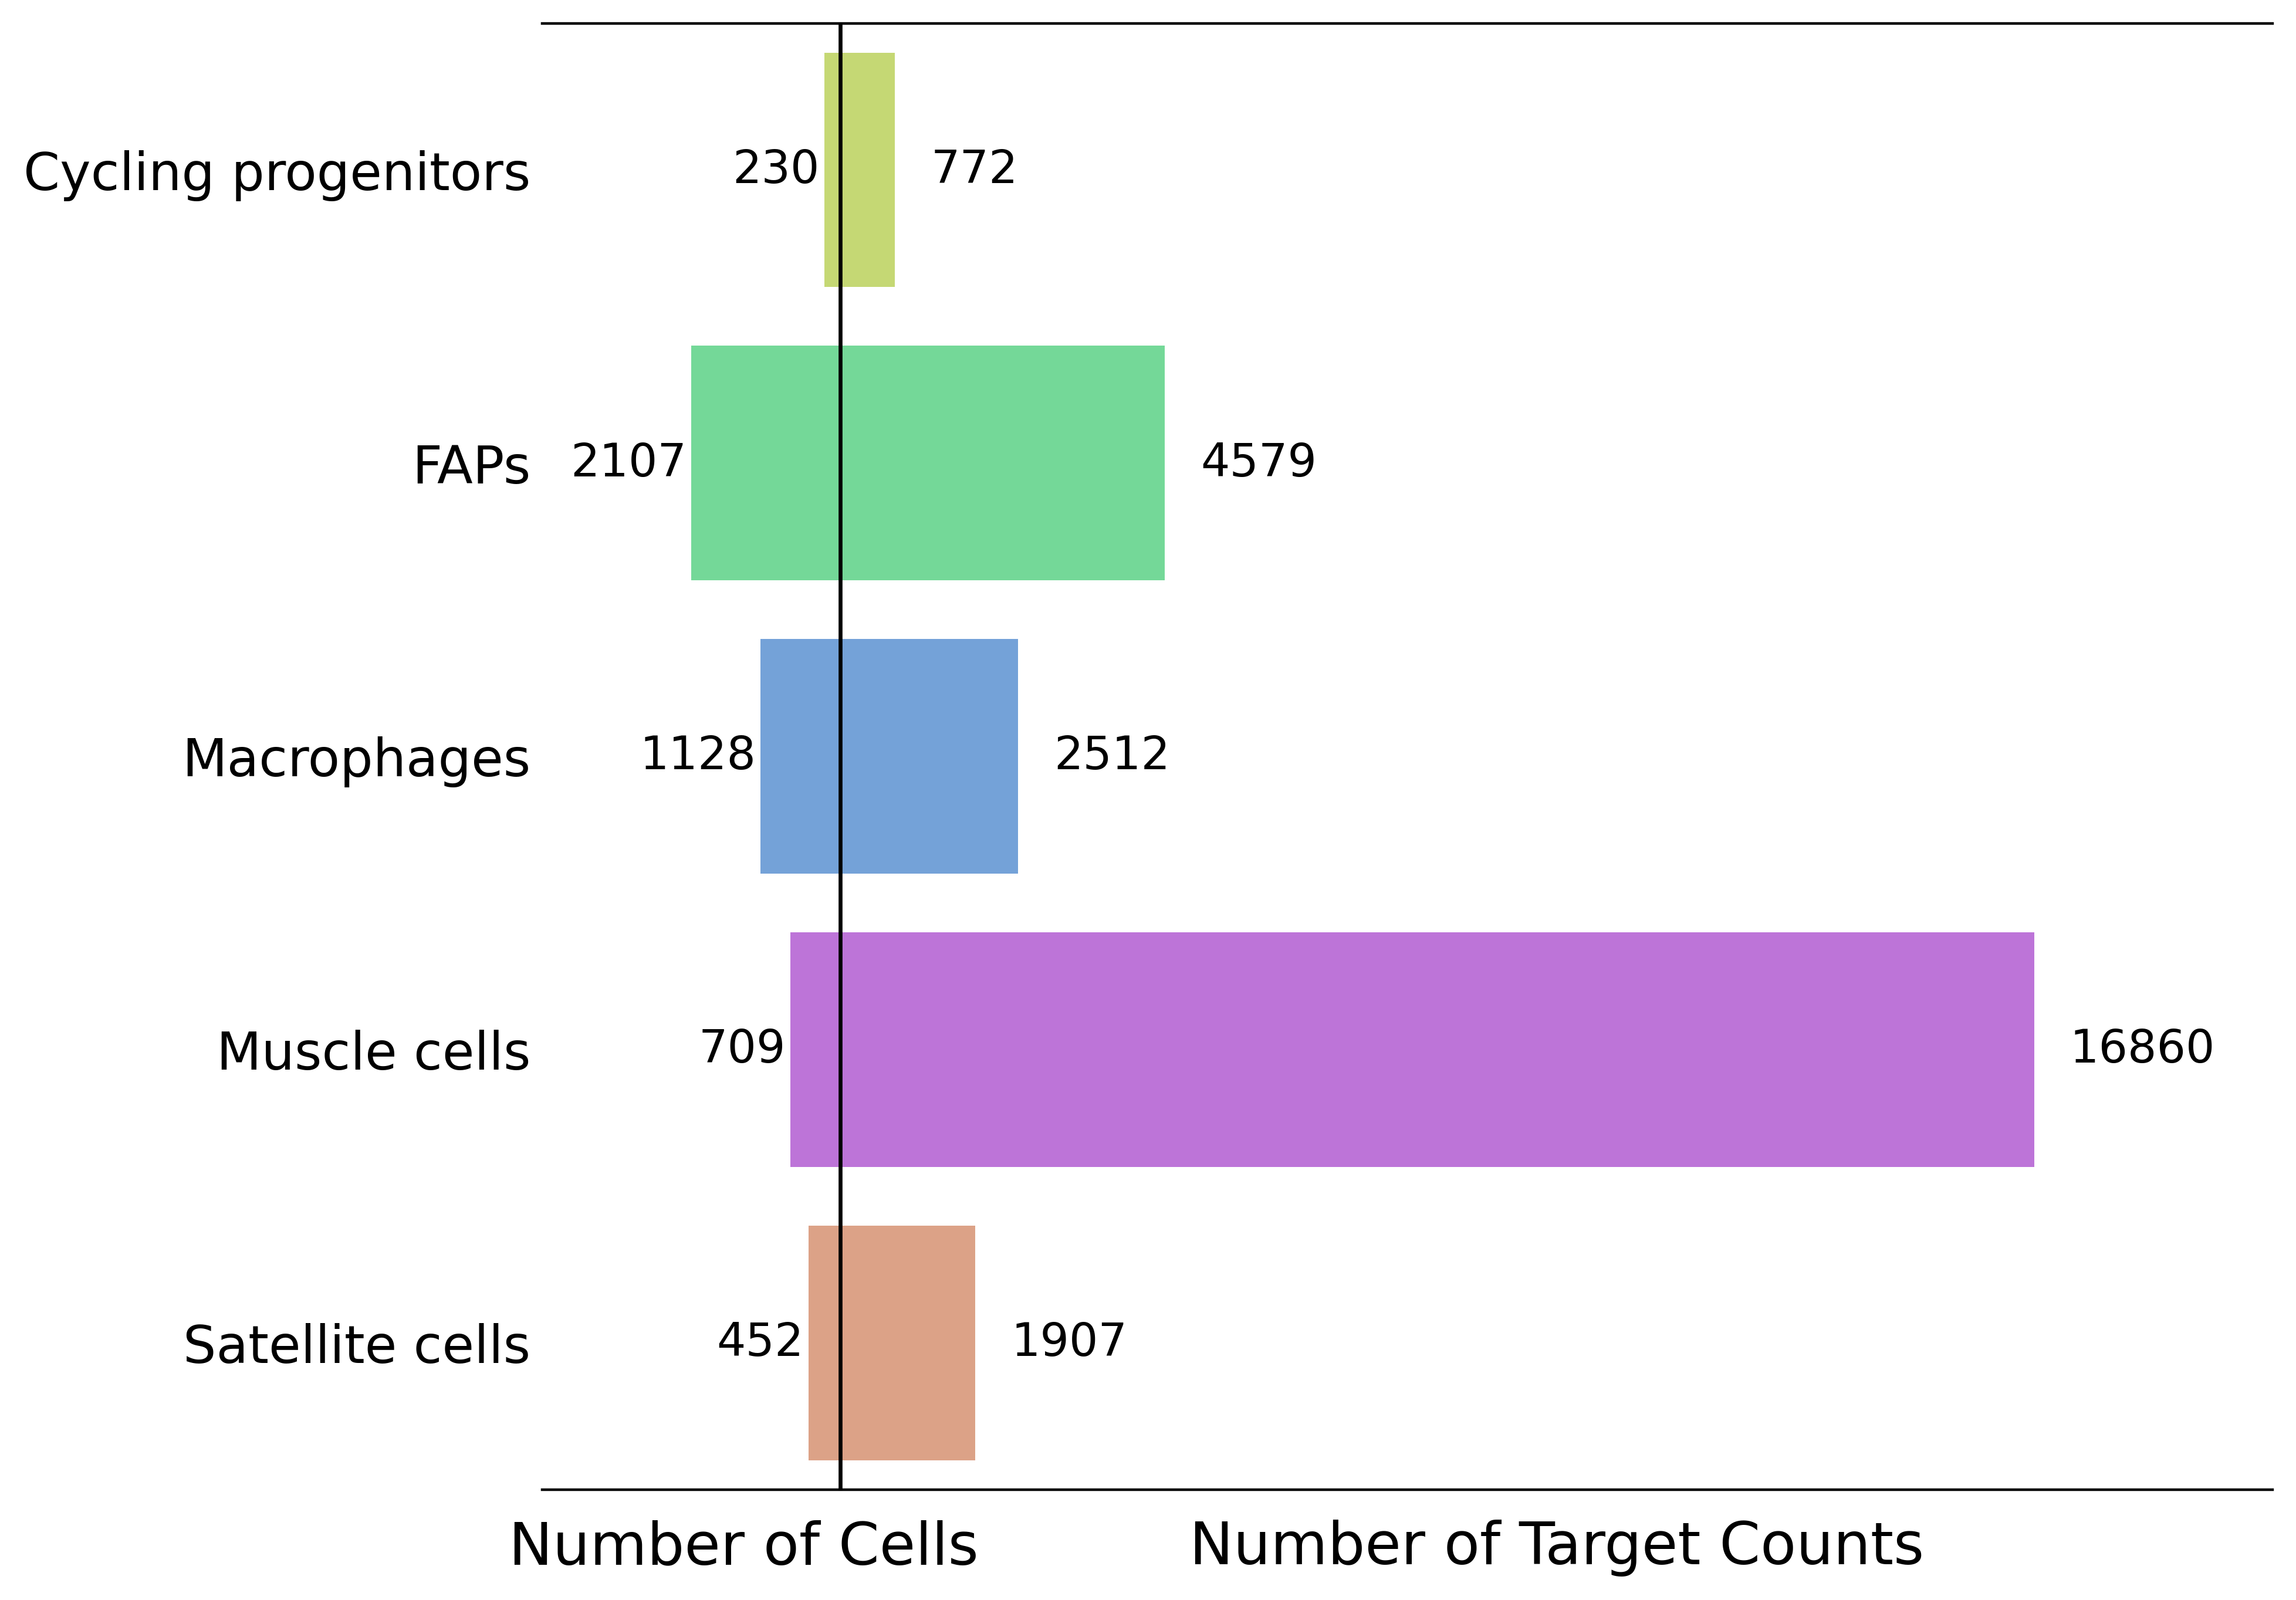

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib as mpl

mpl.rcParams['font.family'] = 'arial'
mpl.rcParams['pdf.fonttype'] = 42   # 关键：TrueType，不转路径
mpl.rcParams['ps.fonttype']  = 42

# 示例数据
# cell_types_df = pd.DataFrame({'cell_type': [...], 'count': [...]})
# target_counts = pd.DataFrame({'cell_type': [...], 'total': [...]})

# 统一 cell_type 顺序
cell_order = sorted(set(cell_types_df['cell_type']).union(set(target_counts['cell_type'])))
cell_types_df = cell_types_df.set_index('cell_type').reindex(cell_order).reset_index()
target_counts = target_counts.set_index('cell_type').reindex(cell_order).reset_index()

# 自定义颜色
colors = ['#d0e963', '#63e993', '#63a0e9', '#c463e9','#ea9d79']

# 创建画布
fig, ax = plt.subplots(figsize=(10, 7))

# 左侧柱子
sns.barplot(
    x=-cell_types_df['count'],
    y=cell_types_df['cell_type'],
    palette=colors,
    ax=ax
)

# 右侧柱子
sns.barplot(
    x=target_counts['total'],
    y=target_counts['cell_type'],
    palette=colors,
    ax=ax
)

# 添加数值标签
for i, (count, total) in enumerate(zip(cell_types_df['count'], target_counts['total'])):
    ax.text(-count - max(cell_types_df['count']) * 0.03, i, str(int(count)),
            va='center', ha='right', fontsize=14)
    ax.text(total + max(target_counts['total']) * 0.03, i, str(int(total)),
            va='center', ha='left', fontsize=14)

# 中间竖线（浅灰）
ax.axvline(0, color='black', linewidth=1.2)

# 去掉不必要元素
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='y', length=0)
for spine in ['left', 'right']:
    ax.spines[spine].set_visible(False)

# 对称坐标范围
max_left = max(cell_types_df['count'])
max_right = max(target_counts['total'])
ax.set_xlim(-max_left * 2, max_right * 1.2)

# 去掉顶部和右侧边框
#sns.despine(top=True, right=True, left=True, bottom=True)

# 移除图例
ax.legend().set_visible(False)

# 左右标题
ax.text(-max_left * 0.65, len(cell_order)-0.3, "Number of Cells",
        ha='center', va='center', fontsize=18)
ax.text(max_right * 0.6, len(cell_order)-0.3, "Number of Target Counts",
        ha='center', va='center', fontsize=18)
ax.set_yticklabels(cell_order, fontsize=16)

# 保存
plt.tight_layout()
plt.savefig("cell_type_mirror_barplot_custom_colors.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


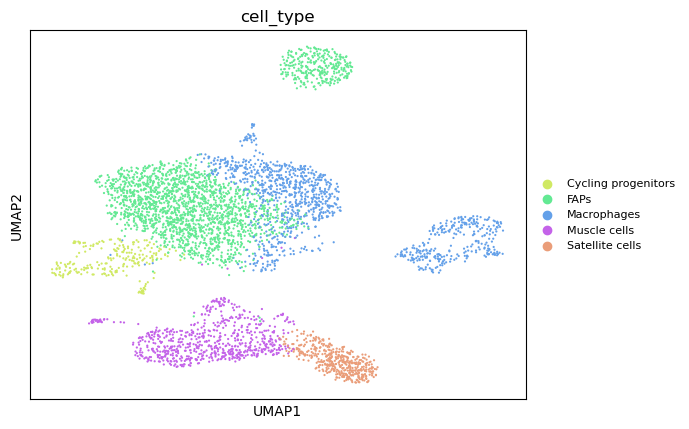

In [8]:
import scanpy as sc

# 你的自定义颜色列表（按 cell_type 顺序）
custom_colors = ['#d0e963', '#63e993', '#63a0e9', '#c463e9','#ea9d79']
# 设置颜色
adata.uns['cell_type_colors'] = custom_colors

# 绘制 UMAP
sc.pl.umap(
    adata,
    color=["cell_type"],
    #frameon=False,
    legend_loc='right margin',  # 或 'right margin' 更整洁
    size=10,
    legend_fontsize=8,
    save='_cell_type_umap.pdf',

)


In [25]:
import pandas as pd
import itertools
import scipy.stats as stats 
cell_type_allele = pd.read_csv('eletroporation_cell_type_allele.csv')
input_allele = pd.read_csv('XNN-scRNA-ORI-input_1.snp.tsv',sep='\t',header=0)
cell_type_allele[['snp_id','region']] = cell_type_allele['snp_id'].str.split('::',expand=True)
cell_type_allele = pd.merge(cell_type_allele,input_allele,on='snp_id',how='left')
cell_type_allele = cell_type_allele.fillna(0)
bulk_starr = pd.read_csv('/data2/chenruipu/data/xulingna/snp/M18_gwas_snp_respectively_gwas_info.csv')
cell_type_allele = cell_type_allele[cell_type_allele['snp_id'].isin(list(bulk_starr['snp_id']))]

In [26]:
cell_type_allele

,snp_id,cell_type,ref_nsnp,ref_ncell,alt_nsnp,alt_ncell,fisher_p-value,region,ref_count,alt_count
0,chr6:34311624:T:G,FAPs,0,0,65,50,1.000000,chr6:34311584-34311744,6661.0,1324.0
1,chr6:32255481:T:C,FAPs,95,90,57,49,0.715721,chr6:32255441-32255601,0.0,0.0
4,chr20:35361116:A:G,FAPs,76,72,77,74,1.000000,chr20:35361076-35361236,4545.0,3446.0
5,chr20:35471850:G:A,FAPs,169,157,76,73,0.921241,chr20:35471810-35471970,4635.0,3351.0
6,chr6:109738751:G:A,FAPs,219,190,177,137,0.452248,chr6:109738711-109738871,4624.0,3347.0
...,...,...,...,...,...,...,...,...,...,...
108,chr7:45941152:G:T,Satellite cells,90,22,97,24,1.000000,chr7:45941112-45941272,4311.0,3702.0
109,chr20:35471711:A:G,Satellite cells,13,6,27,9,0.751617,chr20:35471671-35471831,3771.0,4216.0
111,chr20:35388671:G:C,Satellite cells,39,7,36,11,0.432327,chr20:35388631-35388791,4242.0,3740.0
113,chr20:34583483:G:A,Satellite cells,49,18,63,20,0.709984,chr20:34583443-34583603,4211.0,3794.0


In [32]:
import pandas as pd
f = open ('eletroporation_cell_type_allele_frq_change.csv','w')
f.write('snp_id,scRNA_region,cell_type,input_ref_counts,input_alt_counts,cell_ref_counts,cell_alt_counts,input_alt_frq,output_alt_frq,p_value\n')
for snp in set(list(cell_type_allele['snp_id'])):
	for cell_type in set(list(cell_type_allele['cell_type'])):
		tmp_data = cell_type_allele[(cell_type_allele['snp_id']==snp)&(cell_type_allele['cell_type']==cell_type)]
		input_ref_counts = tmp_data['ref_count'].values[0]
		input_alt_counts = tmp_data['alt_count'].values[0]
		cell_ref_counts = tmp_data['ref_nsnp'].values[0]
		cell_alt_counts = tmp_data['alt_nsnp'].values[0]
		region = tmp_data['region'].values[0]
		table = [[input_ref_counts,input_alt_counts],[cell_ref_counts,cell_alt_counts]]
		oddsratio, p_value = stats.fisher_exact(table)
		print(f'{snp},{cell_type},{p_value}')
		f.write(f'{snp},{snp}::{region},{cell_type},{input_ref_counts},{input_alt_counts},{cell_ref_counts},{cell_alt_counts},{input_alt_counts/(input_ref_counts+input_alt_counts)},{cell_alt_counts/(cell_ref_counts+cell_alt_counts)},{p_value}\n')
f.close()

chr20:35471850:G:A,FAPs,0.0006008978885216839
chr20:35471850:G:A,Satellite cells,0.3781555190340641
chr20:35471850:G:A,Muscle cells,0.22199246164637698
chr20:35471850:G:A,Cycling progenitors,1.0
chr20:35471850:G:A,Macrophages,0.8009953375618859
chr20:35471711:A:G,FAPs,0.0648304173014442
chr20:35471711:A:G,Satellite cells,0.07974417775094017
chr20:35471711:A:G,Muscle cells,1.530437255515757e-07
chr20:35471711:A:G,Cycling progenitors,0.5885770681926756
chr20:35471711:A:G,Macrophages,0.7108550462189585
chr20:34583483:G:A,FAPs,0.3438343348994333
chr20:34583483:G:A,Satellite cells,0.07006827062823548
chr20:34583483:G:A,Muscle cells,0.3748887355418825
chr20:34583483:G:A,Cycling progenitors,0.5844484493231048
chr20:34583483:G:A,Macrophages,0.030594521089560844
chr6:34311623:G:A,FAPs,5.080523184768597e-34
chr6:34311623:G:A,Satellite cells,3.314729277705836e-14
chr6:34311623:G:A,Muscle cells,7.372057967902132e-126
chr6:34311623:G:A,Cycling progenitors,0.0003141315779493244
chr6:34311623:G:A,Mac

/tmp/ipykernel_162558/2840304865.py:15: RuntimeWarning: invalid value encountered in scalar divide
  f.write(f'{snp},{snp}::{region},{cell_type},{input_ref_counts},{input_alt_counts},{cell_ref_counts},{cell_alt_counts},{input_alt_counts/(input_ref_counts+input_alt_counts)},{cell_alt_counts/(cell_ref_counts+cell_alt_counts)},{p_value}\n')


In [1]:
import pandas as pd 
cell_type_alle_frq = pd.read_csv('eletroporation_cell_type_allele_frq_change.csv')

In [2]:
counts_cols = [
	'input_ref_counts',
	'input_alt_counts',
	'cell_ref_counts',
	'cell_alt_counts'
]

cell_type_inner_change_snp = cell_type_alle_frq[((cell_type_alle_frq[counts_cols] >= 30).all(axis=1))&(cell_type_alle_frq['p_value']<0.05)&(cell_type_alle_frq['input_alt_frq']>0.1)&(cell_type_alle_frq['input_alt_frq']<0.9)&(cell_type_alle_frq['output_alt_frq']>0.1)&(cell_type_alle_frq['output_alt_frq']<0.9)]
#cell_type_alle_frq[((cell_type_alle_frq[counts_cols] >= 50).all(axis=1))&(cell_type_alle_frq['p_value']<0.05)&(cell_type_alle_frq['input_alt_frq']>0.1)&(cell_type_alle_frq['input_alt_frq']<0.9)&(cell_type_alle_frq['output_alt_frq']>0.1)&(cell_type_alle_frq['output_alt_frq']<0.9)].to_csv('cell_type_alle_frq_change_50counts.tsv',sep='\t',index=False)

In [3]:
cell_type_inner_change_snp

,snp_id,scRNA_region,cell_type,input_ref_counts,input_alt_counts,cell_ref_counts,cell_alt_counts,input_alt_frq,output_alt_frq,p_value
0,chr20:35471850:G:A,chr20:35471850:G:A::chr20:35471810-35471970,FAPs,4635.0,3351.0,169,76,0.419609,0.310204,6.008979e-04
7,chr20:35471711:A:G,chr20:35471711:A:G::chr20:35471671-35471831,Muscle cells,3771.0,4216.0,183,334,0.527858,0.646035,1.530437e-07
14,chr20:34583483:G:A,chr20:34583483:G:A::chr20:34583443-34583603,Macrophages,4211.0,3794.0,44,61,0.473954,0.580952,3.059452e-02
21,chr7:45928488:G:C,chr7:45928488:G:C::chr7:45928448-45928608,Satellite cells,4263.0,3729.0,30,46,0.466592,0.605263,2.031648e-02
22,chr7:45928488:G:C,chr7:45928488:G:C::chr7:45928448-45928608,Muscle cells,4263.0,3729.0,487,345,0.466592,0.414663,4.361778e-03
25,chr20:35388671:G:C,chr20:35388671:G:C::chr20:35388631-35388791,FAPs,4242.0,3740.0,97,43,0.468554,0.307143,1.518578e-04
30,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,FAPs,4311.0,3702.0,157,180,0.461999,0.534125,1.026348e-02
32,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,Muscle cells,4311.0,3702.0,527,597,0.461999,0.531139,1.413042e-05
34,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,Macrophages,4311.0,3702.0,77,95,0.461999,0.552326,2.034515e-02
57,chr20:35372647:T:C,chr20:35372647:T:C::chr20:35372607-35372767,Muscle cells,4424.0,3588.0,452,307,0.447828,0.404480,2.185595e-02


In [4]:
from numpy import log2
starr_seq_snp =  pd.read_csv('/data2/chenruipu/data/xulingna/snp/M18_effective_snp_eQTL_TF.tsv',sep='\t')
overlap = pd.merge(cell_type_inner_change_snp,starr_seq_snp,on='snp_id',how='inner')
overlap = overlap[['snp_id','cell_type','input_ref_counts','input_alt_counts','cell_ref_counts','cell_alt_counts','p_value','tss_distance','gene_name','LFC_dif']].drop_duplicates()
overlap['scLFC_dif'] = log2((overlap['cell_alt_counts']/overlap['input_alt_counts'])/(overlap['cell_ref_counts']/overlap['input_ref_counts']))

In [5]:
overlap

,snp_id,cell_type,input_ref_counts,input_alt_counts,cell_ref_counts,cell_alt_counts,p_value,tss_distance,gene_name,LFC_dif,scLFC_dif
0,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,59709.0,UQCC1,-2.673275,-0.684974
3,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,-192909.0,CPNE1,-2.673275,-0.684974
4,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,-135712.0,FER1L4,-2.673275,-0.684974
8,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,16686.0,CEP250,-2.673275,-0.684974
9,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,-72897.0,RPL36P4,-2.673275,-0.684974
...,...,...,...,...,...,...,...,...,...,...,...
1175,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,-225518.0,NFS1,2.107090,0.701088
1177,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,-133809.0,FER1L4,2.107090,0.701088
1178,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,61612.0,UQCC1,2.107090,0.701088
1182,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,-70994.0,RPL36P4,2.107090,0.701088


In [37]:
overlap.to_csv('electroporation_cell_type_allele_frq_change_starrseq_overlap.tsv',sep='\t',index=False)

In [6]:
overlap

,snp_id,cell_type,input_ref_counts,input_alt_counts,cell_ref_counts,cell_alt_counts,p_value,tss_distance,gene_name,LFC_dif,scLFC_dif
0,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,59709.0,UQCC1,-2.673275,-0.684974
3,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,-192909.0,CPNE1,-2.673275,-0.684974
4,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,-135712.0,FER1L4,-2.673275,-0.684974
8,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,16686.0,CEP250,-2.673275,-0.684974
9,chr20:35471850:G:A,FAPs,4635.0,3351.0,169,76,0.000601,-72897.0,RPL36P4,-2.673275,-0.684974
...,...,...,...,...,...,...,...,...,...,...,...
1175,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,-225518.0,NFS1,2.107090,0.701088
1177,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,-133809.0,FER1L4,2.107090,0.701088
1178,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,61612.0,UQCC1,2.107090,0.701088
1182,chr20:35473753:C:T,Muscle cells,4346.0,3662.0,73,100,0.001965,-70994.0,RPL36P4,2.107090,0.701088


In [7]:
from numpy import log2
starr_seq_snp =  pd.read_csv('/data2/chenruipu/data/xulingna/snp/M18_effective_snp_eQTL_TF_female.tsv',sep='\t')
overlap = pd.merge(cell_type_inner_change_snp,starr_seq_snp,on='snp_id',how='inner')
overlap = overlap[['snp_id','scRNA_region','cell_type','input_ref_counts','input_alt_counts','cell_ref_counts','cell_alt_counts','input_alt_frq','output_alt_frq','p_value','geneSymbol','LFC_dif','tss_distance','effect','gene_name','average_egene_tpm','average_TF_tpm']].drop_duplicates()
overlap['scLFC_dif'] = log2((overlap['cell_alt_counts']/overlap['input_alt_counts'])/(overlap['cell_ref_counts']/overlap['input_ref_counts']))
#overlap = overlap[overlap['effect']=='strong']

In [8]:
overlap

,snp_id,scRNA_region,cell_type,input_ref_counts,input_alt_counts,cell_ref_counts,cell_alt_counts,input_alt_frq,output_alt_frq,p_value,geneSymbol,LFC_dif,tss_distance,effect,gene_name,average_egene_tpm,average_TF_tpm,scLFC_dif
0,chr20:35471850:G:A,chr20:35471850:G:A::chr20:35471810-35471970,FAPs,4635.0,3351.0,169,76,0.419609,0.310204,0.000601,GMEB2,-2.673275,-72897.0,strong,RPL36P4,0.368425,7.157710,-0.684974
1,chr20:35471850:G:A,chr20:35471850:G:A::chr20:35471810-35471970,FAPs,4635.0,3351.0,169,76,0.419609,0.310204,0.000601,GMEB2,-2.673275,-135712.0,strong,FER1L4,0.298268,7.157710,-0.684974
2,chr20:35471850:G:A,chr20:35471850:G:A::chr20:35471810-35471970,FAPs,4635.0,3351.0,169,76,0.419609,0.310204,0.000601,CUX1,-2.673275,59709.0,strong,UQCC1,23.951592,12.778315,-0.684974
3,chr20:35471850:G:A,chr20:35471850:G:A::chr20:35471810-35471970,FAPs,4635.0,3351.0,169,76,0.419609,0.310204,0.000601,GMEB2,-2.673275,59709.0,strong,UQCC1,23.951592,7.157710,-0.684974
4,chr20:35471850:G:A,chr20:35471850:G:A::chr20:35471810-35471970,FAPs,4635.0,3351.0,169,76,0.419609,0.310204,0.000601,CUX1,-2.673275,-72897.0,strong,RPL36P4,0.368425,12.778315,-0.684974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,chr20:35473753:C:T,chr20:35473753:C:T::chr20:35473713-35473873,Muscle cells,4346.0,3662.0,73,100,0.457293,0.578035,0.001965,POU5F1,2.107090,-133809.0,weak,FER1L4,0.298268,0.541702,0.701088
627,chr20:35473753:C:T,chr20:35473753:C:T::chr20:35473713-35473873,Muscle cells,4346.0,3662.0,73,100,0.457293,0.578035,0.001965,POU5F1,2.107090,61612.0,strong,UQCC1,23.951592,0.541702,0.701088
628,chr20:35473753:C:T,chr20:35473753:C:T::chr20:35473713-35473873,Muscle cells,4346.0,3662.0,73,100,0.457293,0.578035,0.001965,"OCT4-SOX2-TCF-NANOG(POU,Homeobox,HMG)/mES-Oct4...",2.107090,-70994.0,strong,RPL36P4,0.368425,NaN,0.701088
631,chr20:35473753:C:T,chr20:35473753:C:T::chr20:35473713-35473873,Muscle cells,4346.0,3662.0,73,100,0.457293,0.578035,0.001965,POU5F1,2.107090,-225518.0,weak,NFS1,12.955628,0.541702,0.701088


/tmp/ipykernel_162558/1013748718.py:66: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
/tmp/ipykernel_162558/1013748718.py:66: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
/tmp/ipykernel_162558/1013748718.py:66: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


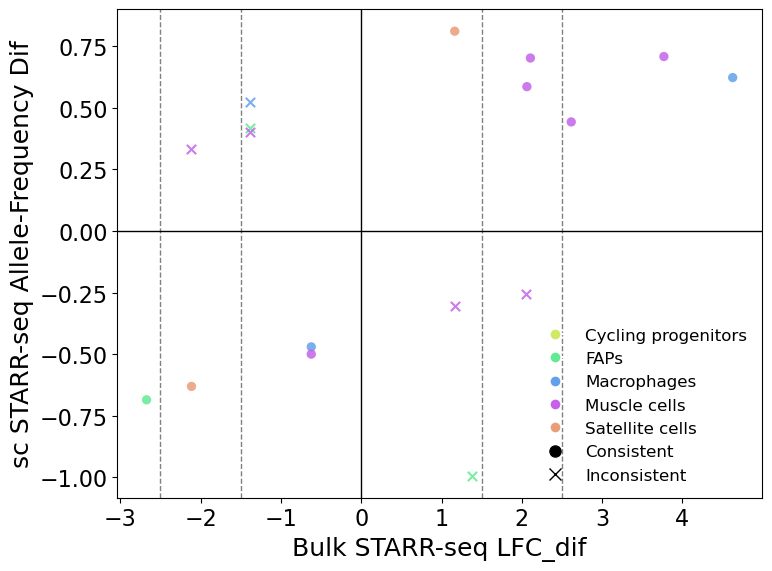

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import linregress


plt.rcParams.update({
    'font.size': 16,          # 默认字体大小（影响大多数元素）
    'axes.titlesize': 16,     # 坐标轴标题
    'axes.labelsize': 16,     # x/y 轴 label
    'xtick.labelsize': 16,    # x 轴刻度
    'ytick.labelsize': 16,    # y 轴刻度
    'legend.fontsize': 12,    # 图例文字
    'legend.title_fontsize': 18
})



# =========================
# 1. 数据准备
# =========================
df = overlap[['LFC_dif', 'scLFC_dif', 'cell_type']].drop_duplicates()

# 一致性判定（英文）
df['consistency'] = np.where(
    (df['LFC_dif'] > 0) & (df['scLFC_dif'] > 0) |
    (df['LFC_dif'] < 0) & (df['scLFC_dif'] < 0),
    'Consistent', 'Inconsistent'
)

# LFC 区域分类
def region_class(x):
    if abs(x) < 1.5:
        return '|LFC_dif| < 1.5'
    elif abs(x) < 2.5:
        return '1.5 ≤ |LFC_dif| < 2.5'
    else:
        return '|LFC_dif| ≥ 2.5'

df['region'] = df['LFC_dif'].apply(region_class)

# =========================
# 2. 颜色 & 形状定义
# =========================
cell_color_map = {
    'Cycling progenitors': '#d0e963',
    'FAPs': '#63e993',
    'Macrophages': '#63a0e9',
    'Muscle cells': '#c463e9',
    'Satellite cells': '#ea9d79'
}

marker_map = {
    'Consistent': 'o',
    'Inconsistent': 'x'
}

# =========================
# 3. 绘图
# =========================
plt.figure(figsize=(8, 6))

for cell_type, sub_df in df.groupby('cell_type'):
    for consistency, sub2 in sub_df.groupby('consistency'):
        plt.scatter(
            sub2['LFC_dif'],
            sub2['scLFC_dif'],
            c=cell_color_map.get(cell_type, 'gray'),
            marker=marker_map[consistency],
            s=45,
            alpha=0.85,
            edgecolors='none'
        )

# X 轴分区虚线
for x in [-2.5, -1.5, 1.5, 2.5]:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)

# 坐标轴
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)


# =========================
# 5. 图例
# =========================
cell_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=c, markersize=8, label=ct)
    for ct, c in cell_color_map.items()
]

consistency_legend = [
    Line2D([0], [0], marker='o', color='black',
           linestyle='None', markersize=8, label='Consistent'),
    Line2D([0], [0], marker='x', color='black',
           linestyle='None', markersize=8, label='Inconsistent')
]

plt.legend(handles=cell_legend + consistency_legend,
           title='', frameon=False, loc='lower right')

# =========================
# 6. 标签 & 保存
# =========================
plt.xlabel('Bulk STARR-seq LFC_dif', fontsize=18)
plt.ylabel('sc STARR-seq Allele-Frequency Dif', fontsize=18)
plt.tight_layout()
plt.savefig(
    "scLFC_dif_vs_LFC_dif_with_regression.pdf",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [50]:
pseudo_bulk = pd.merge(overlap[['snp_id','LFC_dif','input_ref_counts','input_alt_counts']].drop_duplicates(),target_counts,on='snp_id',how='inner')

In [51]:
pseudo_bulk['scLFC_dif'] = np.log2((pseudo_bulk['alt_nsnp']/pseudo_bulk['ref_nsnp'])/(pseudo_bulk['input_alt_counts']/pseudo_bulk['input_ref_counts']))

,snp_id,LFC_dif,input_ref_counts,input_alt_counts,ref_nsnp,alt_nsnp,scLFC_dif,color
0,chr20:35471850:G:A,-2.673275,4635.0,3351.0,855,542,-0.189654,#ea9d79
1,chr20:35471711:A:G,3.769816,3771.0,4216.0,275,469,0.609229,#ea9d79
2,chr20:34583483:G:A,4.626660,4211.0,3794.0,629,650,0.197823,#ea9d79
3,chr7:45928488:G:C,1.164556,4263.0,3729.0,777,607,-0.163138,#63a0e9
4,chr20:35388671:G:C,1.376101,4242.0,3740.0,501,384,-0.201998,#63a0e9
5,chr7:45941152:G:T,-1.379289,4311.0,3702.0,875,993,0.402228,#63a0e9
6,chr20:35372647:T:C,2.049358,4424.0,3588.0,652,476,-0.151739,#63a0e9
7,chr12:123957333:C:G,-0.622196,3873.0,4141.0,1371,1123,-0.384398,#ea9d79
8,chr20:35361116:A:G,2.063471,4545.0,3446.0,470,477,0.420686,#ea9d79
9,chr20:34990448:A:G,2.615810,3524.0,4468.0,410,678,0.383246,#ea9d79


In [18]:
cell_type_alle_frq

,snp_id,scRNA_region,cell_type,input_ref_counts,input_alt_counts,cell_ref_counts,cell_alt_counts,input_alt_frq,output_alt_frq,p_value
0,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,Muscle cells,4311.0,3702.0,527,597,0.461999,0.531139,0.000014
1,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,Cycling progenitors,4311.0,3702.0,24,24,0.461999,0.500000,0.663906
2,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,FAPs,4311.0,3702.0,157,180,0.461999,0.534125,0.010263
3,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,Satellite cells,4311.0,3702.0,90,97,0.461999,0.518717,0.137801
4,chr7:45941152:G:T,chr7:45941152:G:T::chr7:45941112-45941272,Macrophages,4311.0,3702.0,77,95,0.461999,0.552326,0.020345
...,...,...,...,...,...,...,...,...,...,...
90,chr20:34990448:A:G,chr20:34990448:A:G::chr20:34990408-34990568,Muscle cells,3524.0,4468.0,281,484,0.559059,0.632680,0.000083
91,chr20:34990448:A:G,chr20:34990448:A:G::chr20:34990408-34990568,Cycling progenitors,3524.0,4468.0,5,14,0.559059,0.736842,0.164427
92,chr20:34990448:A:G,chr20:34990448:A:G::chr20:34990408-34990568,FAPs,3524.0,4468.0,56,75,0.559059,0.572519,0.790584
93,chr20:34990448:A:G,chr20:34990448:A:G::chr20:34990408-34990568,Satellite cells,3524.0,4468.0,41,59,0.559059,0.590000,0.545361


In [115]:
adata_raw = sc.read_10x_h5("/data2/chenruipu/data/xulingna/snp/scRNA/20250312_electrorotation/result/electrorotation/outs/raw_feature_bc_matrix.h5")
adata_raw.var_names_make_unique()
adata_raw = adata_raw[adata.obs_names,:]
adata_raw.obs = adata.obs
sc.pp.normalize_total(adata_raw, target_sum=1e4)
sc.pp.log1p(adata_raw)
sc.pp.highly_variable_genes(adata_raw, min_mean=0.0125, max_mean=3, min_disp=0.5)
#sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata_raw, max_value=10)

/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


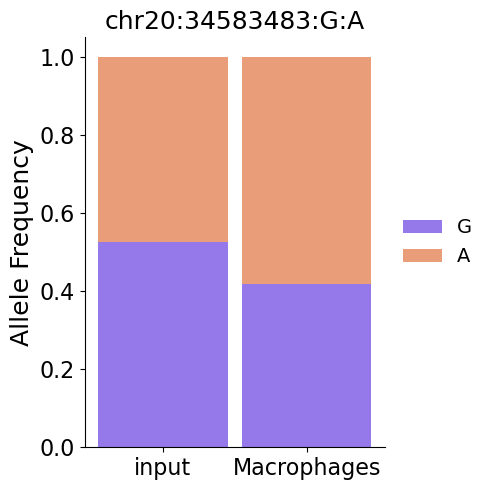

In [5]:
import matplotlib.pyplot as plt
import numpy as np

snp_id = 'chr20:34583483:G:A'
# 样本
samples = ['input','Macrophages']

input_alt_frq = cell_type_inner_change_snp[cell_type_inner_change_snp['snp_id']==snp_id]['input_alt_frq'].to_list()[0]
#macrophages_alt_frq = cell_type_between_change_snp[cell_type_between_change_snp['snp_id']==snp_id]['cell_type1_alt_fq'].to_list()[0]
musclecells_alt_frq = cell_type_inner_change_snp[cell_type_inner_change_snp['snp_id']==snp_id]['output_alt_frq'].to_list()[0]
# 三类细胞的数量
ref = [1-input_alt_frq,1-musclecells_alt_frq]
alt = [input_alt_frq,musclecells_alt_frq]

# 堆叠柱状图
bar_width = 0.9 # 调整宽度
x = np.arange(len(samples))
#x = np.array([0, 0.5])

# 创建图
fig, ax = plt.subplots(figsize=(5,5))

# 去掉上、右边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 绘制柱状图，使用自定义颜色
ax.bar(x, ref, width=bar_width, label=snp_id.split(':')[-2], color='#9579ea')
ax.bar(x, alt, width=bar_width, bottom=ref, label=snp_id.split(':')[-1], color='#ea9d79')

# 设置横轴
ax.set_xticks(x)
ax.set_xticklabels(samples, fontsize=16)
ax.set_xlabel("", fontsize=18)  # 横轴标签

# 设置纵轴
ax.set_ylabel("Allele Frequency", fontsize=18)
ax.tick_params(axis='y', labelsize=16)

# 添加标题
ax.set_title(snp_id, fontsize=18)

# 去掉背景网格线
ax.grid(False)  # ✅ 去掉背景网格
# 图例
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=14)

# 调整布局并保存为 PDF
plt.tight_layout()
plt.savefig(f"{snp_id.replace(':','_')}_allele_barplot_scRNA.pdf", format='pdf', dpi=300)

# 显示图
plt.show()


['#d0e963', '#63e993', '#63a0e9', '#c463e9','#ea9d79']
FAPs,Macrophages, Muscle cell, Proliferating,Satellite

/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/data5/chenruipu/miniconda3/envs/scRNA/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sty

<Figure size 1200x800 with 0 Axes>

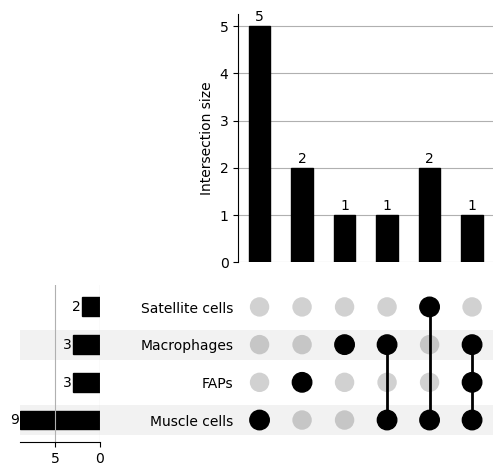

In [22]:
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships
import pandas as pd

# ---- 自定义颜色 ----
color_map = {
    "FAPs": "#63e993",
    "Macrophages": "#63a0e9",
    "Muscle cells": "#c463e9",
    "Satellite cells": "#ea9d79"
}

# ---- 构造集合 ----
A = set(cell_type_inner_change_snp[cell_type_inner_change_snp['cell_type']=='FAPs']['snp_id'])
B = set(cell_type_inner_change_snp[cell_type_inner_change_snp['cell_type']=='Muscle cells']['snp_id'])
C = set(cell_type_inner_change_snp[cell_type_inner_change_snp['cell_type']=='Macrophages']['snp_id'])
D = set(cell_type_inner_change_snp[cell_type_inner_change_snp['cell_type']=='Satellite cells']['snp_id'])

all_snp = A | B | C | D

# ---- membership 格式 ----
memberships = []
for s in all_snp:
    groups = []
    if s in A: groups.append("FAPs")
    if s in B: groups.append("Muscle cells")
    if s in C: groups.append("Macrophages")
    if s in D: groups.append("Satellite cells")
    memberships.append(groups)

data = from_memberships(memberships)

# ---- 绘图 ----
plt.figure(figsize=(12, 8))
up = UpSet(
    data,
    subset_size='count',
    show_counts=True,
    element_size=40
)

# ---- 设置颜色 ----
for cat in up.intersections.index.names:
    up.category_styles[cat] = {"color": color_map[cat]}

up.plot()
plt.tight_layout()
plt.savefig("upset_plot_cell_types.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()


In [4]:
import pandas as pd
df = cell_type_inner_change_snp.copy()

# 将 input 转成长格式
df_input = df[['snp_id', 'input_ref_counts', 'input_alt_counts']].copy()
df_input['cell_type'] = 'input'  # 新增 cell_type
df_input = df_input.rename(columns={
    'input_ref_counts': 'ref_counts',
    'input_alt_counts': 'alt_counts'
})
df_input = df_input[['snp_id', 'cell_type', 'ref_counts', 'alt_counts']]

# 将原来的 cell_type 数据也转换列名统一
df_cell = df[['snp_id', 'cell_type', 'cell_ref_counts', 'cell_alt_counts']].copy()
df_cell = df_cell.rename(columns={
    'cell_ref_counts': 'ref_counts',
    'cell_alt_counts': 'alt_counts'
})
df_cell = df_cell[['snp_id', 'cell_type', 'ref_counts', 'alt_counts']]

# 拼接 input 与 cell_type 数据
df_long = pd.concat([df_cell, df_input], axis=0).reset_index(drop=True)




In [10]:
from numpy import log2
starr_seq_snp =  pd.read_csv('/data2/chenruipu/data/xulingna/snp/M18_effective_snp_eQTL_TF.tsv',sep='\t')
overlap = pd.merge(cell_type_inner_change_snp,starr_seq_snp,on='snp_id',how='inner')
overlap = overlap[['snp_id','cell_type','input_ref_counts','input_alt_counts','cell_ref_counts','cell_alt_counts','p_value','tss_distance','gene_name','LFC_dif']].drop_duplicates()
overlap['scLFC_dif'] = log2((overlap['cell_alt_counts']/overlap['input_alt_counts'])/(overlap['cell_ref_counts']/overlap['input_ref_counts']))
overlap = overlap[overlap['gene_name'].isin(['CPNE1','RPL36P4','GGT7','GSS','ACSS2','UQCC1','CPNE1'])]
#overlap = overlap[~overlap['snp_id'].isin(['chr20:34624251:G:A','chr20:34819901:A:C','chr20:34704973:C:T'])]
#overlap.to_csv('cell_type_inner_change_snp_filtered_bulkLFC.csv',index=False)

In [14]:
import pandas as pd
gwas_info = pd.read_csv('/data2/chenruipu/data/xulingna/snp/M18_gwas_snp_respectively_gwas_info.csv')
snpid_rs = gwas_info[['snp_id','SNP']].drop_duplicates()

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

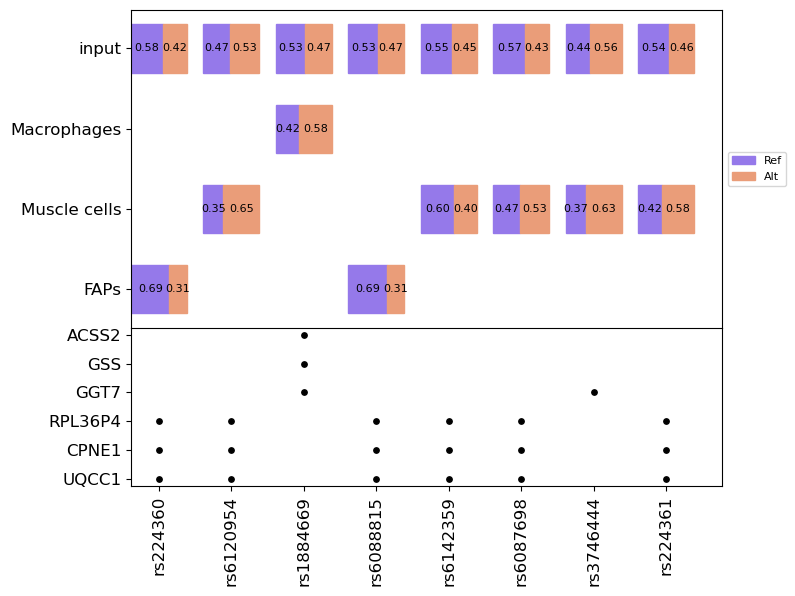

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

mpl.rcParams['font.family'] = 'arial'
mpl.rcParams['pdf.fonttype'] = 42   # 关键：TrueType，不转路径
mpl.rcParams['ps.fonttype']  = 42


plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# 之前筛选的 df_long 数据
df_plot = df_long.copy()
df_plot = df_plot[df_plot['snp_id'].isin(overlap['snp_id'].unique())]
df_plot = pd.merge(df_plot,snpid_rs,on='snp_id',how='left')
df_plot['snp_id'] = df_plot['SNP']
# 点图表格
df_dot = overlap.copy()
df_dot = pd.merge(df_dot,snpid_rs,on='snp_id',how='left')
df_dot['snp_id'] = df_dot['SNP']


# 计算 allele frequency
df_plot['total_counts'] = df_plot['ref_counts'] + df_plot['alt_counts']
df_plot['ref_frq'] = df_plot['ref_counts'] / df_plot['total_counts']
df_plot['alt_frq'] = df_plot['alt_counts'] / df_plot['total_counts']

# 设置 figure 和 gridspec
fig = plt.figure(figsize=(8,6))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 0.5], hspace=0)

# 上方堆叠图
ax1 = fig.add_subplot(gs[0])

cell_types = df_plot['cell_type'].unique()
snps = df_plot['snp_id'].unique()
num_snps = len(snps)

bar_height = 0.6
snp_spacing = 1.3
y_base = np.arange(len(cell_types))

for j, snp in enumerate(snps):
    x_offset = j * snp_spacing
    for i, ct in enumerate(cell_types):
        tmp = df_plot[(df_plot['snp_id']==snp) & (df_plot['cell_type']==ct)]
        if tmp.empty or tmp['total_counts'].values[0]==0:
            continue
        ref_frq = tmp['ref_frq'].values[0]
        alt_frq = tmp['alt_frq'].values[0]
        y_pos = y_base[i]
        ax1.barh(y_pos, ref_frq, height=bar_height, color='#9579ea', edgecolor='#9579ea', left=x_offset)
        ax1.barh(y_pos, alt_frq, height=bar_height, color='#ea9d79', edgecolor='#ea9d79', left=ref_frq + x_offset)
        if ref_frq > 0.05:
            ax1.text(x_offset + ref_frq/2, y_pos, f'{ref_frq:.2f}', va='center', ha='center', fontsize=8)
        if alt_frq > 0.05:
            ax1.text(x_offset + ref_frq + alt_frq/2, y_pos, f'{alt_frq:.2f}', va='center', ha='center', fontsize=8)

ax1.set_yticks(y_base)
ax1.set_yticklabels(cell_types)
ax1.set_ylabel('')
# 隐藏上方图的横坐标和下边框
ax1.set_xticks([])
ax1.set_xlabel('')
ax1.spines['bottom'].set_visible(False)
ax1.get_xaxis().set_visible(False)

ax1.legend(['Ref', 'Alt'], loc='center left', bbox_to_anchor=(1, 0.5))

# 下方点图
ax2 = fig.add_subplot(gs[1], sharex=ax1)

genes = df_dot['gene_name'].unique()
y_genes = np.arange(len(genes))
gene_to_y = {gene: y for y, gene in enumerate(genes)}

for j, snp in enumerate(snps):
    x_offset = j * snp_spacing + 0.5
    tmp = df_dot[df_dot['snp_id']==snp]
    for gene in tmp['gene_name']:
        y_pos = gene_to_y[gene]
        ax2.scatter(x_offset, y_pos, s=15, color='black')

ax2.set_yticks(y_genes)
ax2.set_yticklabels(genes)
ax2.set_xlabel('')
ax2.set_xticks([j * snp_spacing + 0.5 for j in range(num_snps)])
ax2.set_xticklabels(snps, rotation=90)


plt.tight_layout()
plt.savefig("cell_type_inner_filter_targe_gene_snp_id.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()
